In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Matplotlib is building the font cache; this may take a moment.


In [13]:
df = pd.read_csv('noisy_curvefit_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("\nColumn Names:", df.columns.tolist())

print("\nFirst five rows:")
print(df.head())
print("\nLast five rows:")
print(df.tail())

Dataset Shape: (100, 6)
Number of rows: 100
Number of columns: 6

Column Names: ['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


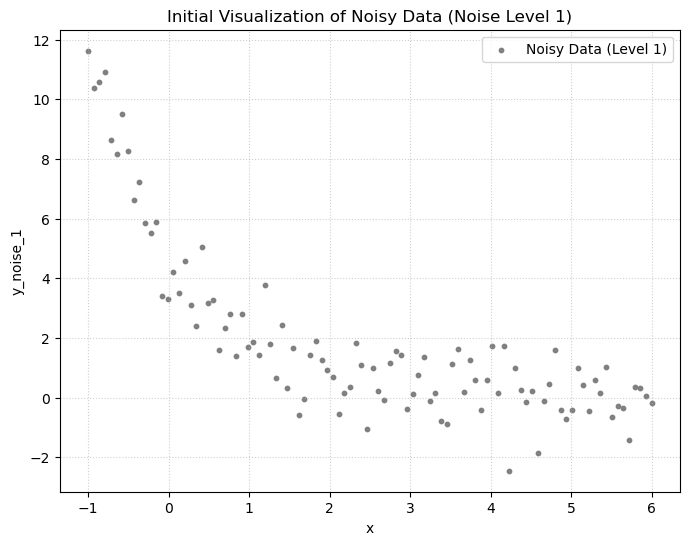

In [14]:
plt.figure(figsize=(8, 6))

# Scatter plot of x vs y_noise_1
plt.scatter(df['x'], df['y_noise_1'], color='gray', label='Noisy Data (Level 1)', s=10)

plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.title('Initial Visualization of Noisy Data (Noise Level 1)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [15]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]

x_data = df['x']
y_data = df['y_noise_1']

popt, pcov = curve_fit(model, x_data, y_data, p0=p0)
A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [16]:
residuals = y_data - model(x_data, A_fit, k_fit)

chi2 = np.sum(residuals**2)

# Degrees of freedom
dof = len(x_data) - len(popt)

chi2_reduced = chi2 / dof

print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")

Reduced Chi-Squared: 0.79


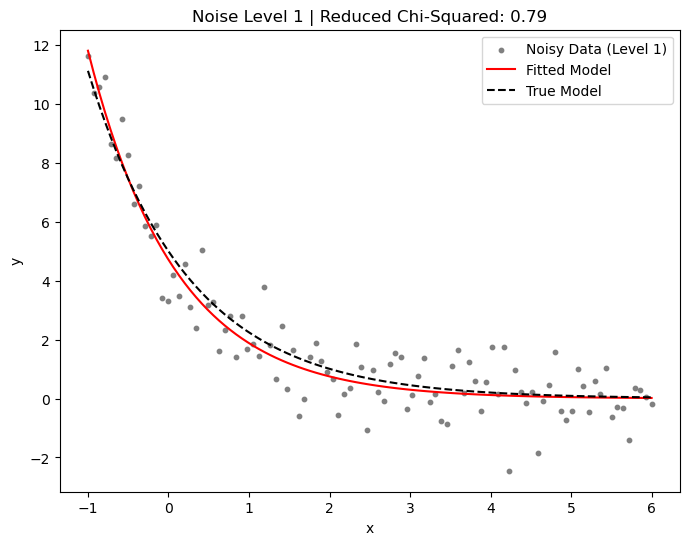

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(x_data, y_data, color='gray', label='Noisy Data (Level 1)', s=10)

plt.plot(x_data, model(x_data, A_fit, k_fit), color='red', label='Fitted Model')

plt.plot(x_data, model(x_data, 5, 0.8), color='black', linestyle='--', label='True Model')

plt.title(f"Noise Level 1 | Reduced Chi-Squared: {chi2_reduced:.2f}")

#Below are labels
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

In [18]:
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=[1, 1])
    
    residuals = y - model(x, *popt)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_red = chi2 / dof
    
    return popt, chi2_red 

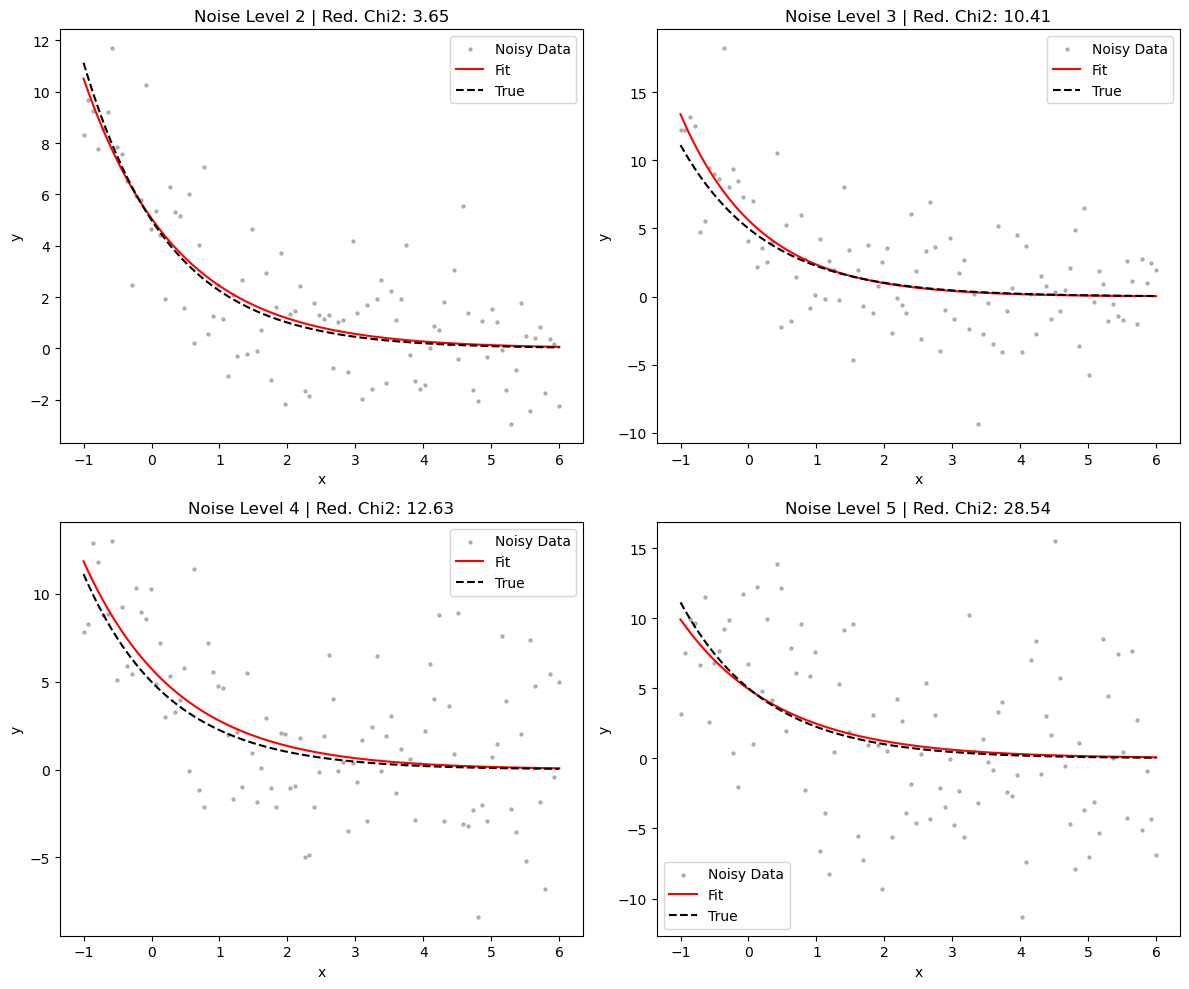

In [19]:
noise_levels = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
plt.figure(figsize=(12, 10))

for i, col in enumerate(noise_levels, 1):
    plt.subplot(2, 2, i) 
    
    y_noisy = df[col]
    
    params, r_chi2 = fit_model(df['x'], y_noisy)
    A_f, k_f = params
    
    plt.scatter(df['x'], y_noisy, color='gray', s=5, alpha=0.5, label='Noisy Data')
    plt.plot(df['x'], model(df['x'], A_f, k_f), color='red', label='Fit')
    plt.plot(df['x'], model(df['x'], 5, 0.8), color='black', linestyle='--', label='True')
    
    plt.title(f"Noise Level {i+1} | Red. Chi2: {r_chi2:.2f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Just initializing lists to store results
noise_levels_list = [1, 2, 3, 4, 5]
a_fits = []
k_fits = []
chi2_results = []

cols = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

for col in cols:
    params, r_chi2 = fit_model(df['x'], df[col])
    a_fits.append(params[0])
    k_fits.append(params[1])
    chi2_results.append(r_chi2)

results_df = pd.DataFrame({
    'Noise Level': noise_levels_list,
    'A_fit': a_fits,
    'k_fit': k_fits,
    'Reduced Chi-Squared': chi2_results
})

print(results_df)

   Noise Level     A_fit     k_fit  Reduced Chi-Squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [21]:
results_df.to_csv("noisy_parameters.csv", index=False)
print("File 'noisy_parameters.csv' has been saved!")

File 'noisy_parameters.csv' has been saved!
